# 1. Quickstart

In [ ]:
%pip install "jax[tpu]"

## 1.1 JAX vs numpy
ok so JAX arrays can be used as a drop in replacement for np arrays (duck-typing!) - the difference is JAX arrays are **immutable!**

In [32]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

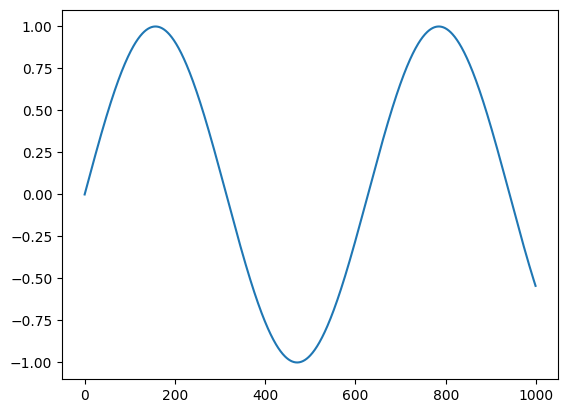

In [3]:
# makin a jax array
jax_arr = jnp.linspace(0, 10, 1000)
plt.plot(jnp.sin(jax_arr))

In [4]:
# notice da different types
x_np = np.array([1, 2, 3])
x_jax = jnp.array([1, 2, 3])

print(type(x_np))
print(type(x_jax))

<class 'numpy.ndarray'>
<class 'jaxlib._jax.ArrayImpl'>


In [5]:
# we know numpy arrays are mutable
x_np[0] = 9
x_np

array([9, 2, 3])

In [6]:
%xmode minimal

Exception reporting mode: Minimal


In [7]:
# but jax arrays are not!
x_jax[0] = 9

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [8]:
# ok so how do we update jax arrays then
y_jax = x_jax.at[0].set(9)
y_jax # <==== this is a copy

y_jax, type(y_jax)

(Array([9, 2, 3], dtype=int32), jaxlib._jax.ArrayImpl)

## 1.2 JAX Arrays

In [15]:
# making da array 
# basically we don't want to use the constructor directly but use the JAX API instead
x = jnp.arange(5)
y = jnp.linspace(0, 10, 100)
z = jnp.zeros(5)

z

Array([0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
# sharding (not sharting lamoaoaoa)
# JAX Array objects have a devices method that lets you inspect where the contents of the array are stored
x.devices()

{TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)}

In [20]:
x.sharding

SingleDeviceSharding(device=TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), memory_kind=device)

## 1.3 JIT Compilation
By default JAX executes operations one at a time, in sequence.

Using a just-in-time (JIT) compilation decorator, sequences of operations can be optimized together and run at once.

Not all JAX code can be JIT compiled, as it requires array shapes to be static & known at compile time.

In [ ]:
# we can use `jax.jit` to compile a sequence of operations together
def norm(X):
    X = X - X.mean()
    return X / X.std()

Array([-1.4142137, -0.7071068,  0.       ,  0.7071068,  1.4142137],      dtype=float32)

In [38]:
# ok so let's now create a JIT compiled version (it's faster!):
from jax import jit
norm_compiled = jax.jit(norm)

np.allclose(norm_compiled(jnp.arange(5)), norm(jnp.arange(5)))

X = jnp.array(np.random.rand(10000, 10))
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

323 µs ± 7.82 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
139 µs ± 7.43 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


ok but what about the **limitations?** (static shapes)
- the biggest things is jit compilation requires arrays to be **STATIC SIZE**.

In [55]:
# example of jit not working
def get_negatives(x):
    return x[x < 0]

get_negatives_compiled = jax.jit(get_negatives)

print(get_negatives(jnp.arange(-5, 5)))
print(get_negatives_compiled(jnp.arange(-5, 5)))

# this doesn't work because the function generates an array whose size is unknown(!!!) at compile time
# i.e. size of output depends on the values of the input array... (so not compatible w/ jit)

[-5 -4 -3 -2 -1]


NonConcreteBooleanIndexError: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

## 1.4 Taking Derivatives w/ `jax.grad`
this is doin autodiff! (with `jax.grad`)
`jax.grad` and `jax.jit` transformations can compose and be mixed arbitrarily (It means JAX transformations can wrap each other in different orders.)

In [57]:
# means you can do stuff like this
grad_f = jax.grad(f)          # derivative function
fast_grad_f = jax.jit(grad_f) # compile the derivative

NameError: name 'f' is not defined

In [64]:
# doing autodiff on the logistic function
from jax import grad

def sum_logistic(x):
    return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

derivative_fn = grad(sum_logistic)
print(derivative_fn(jnp.arange(5.)))


[0.25       0.19661197 0.10499357 0.04517667 0.01766271]


In [73]:
# getting the jacobian
from jax import jacobian, hessian

x_small = jnp.arange(3.)

print(jacobian(jnp.exp)(x_small)) 

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [ ]:
from jax import jacfwd, jacrev

# we do this typically in ml because the reverse jacobian is v^T J - you start at the output and propagate gradients backwards
def hessian(X):
    return jit(jacfwd(jacrev(X)))

hessian(sum_logistic)(x_small)
# cuz the hessian() returns a function and we call it with x_small now

Array([[-0.        , -0.        , -0.        ],
       [-0.        , -0.09085776, -0.        ],
       [-0.        , -0.        , -0.07996249]], dtype=float32)